# 3. Task 2.3: Recommender System

Two approaches:
1. **Content-based**: recommend trails similar to a query trail using cosine similarity on each of our 4 vectorizations
2. **Collaborative filtering**: simulate user-trail interactions from `rating_score` and compare SVD vs KNN with the Surprise library

At the end we compare both approaches.

In [1]:
# surprise is not happy with numpy
!pip install scikit-surprise "numpy<2"

In [2]:
# Connect to Google Drive
from google.colab import drive
from pathlib import Path

colab = True

if colab:
    drive.mount("/content/drive")
    #DIRECTORY = "/content/drive/MyDrive/YEAR 4 - SPRING/ML Applications/ml-applications-project-repo"
    DIRECTORY = "/content/drive/MyDrive/ml-applications-project-repo"
else:
    DIRECTORY = ".."

PROJECT_ROOT = Path(DIRECTORY)
DATA_DIR = PROJECT_ROOT / "data"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("Data folder exists:", DATA_DIR.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT: /content/drive/MyDrive/ml-applications-project-repo
DATA_DIR: /content/drive/MyDrive/ml-applications-project-repo/data
Data folder exists: True


In [3]:
import sys
import pickle
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Compatibility fix for pickles created with NumPy 2.x but loaded with NumPy 1.x
try:
    import numpy.core.numeric as numeric
    import numpy.core.multiarray as multiarray
    import numpy.core._multiarray_umath as multiarray_umath

    sys.modules["numpy._core"] = np.core
    sys.modules["numpy._core.numeric"] = numeric
    sys.modules["numpy._core.multiarray"] = multiarray
    sys.modules["numpy._core._multiarray_umath"] = multiarray_umath
except Exception:
    pass

# Prefer CSV if it already exists, because it avoids NumPy pickle issues
csv_path = DATA_DIR / "trails.csv"
pkl_numpy1_path = DATA_DIR / "trails_numpy1.pkl"
pkl_path = DATA_DIR / "trails.pkl"
pkl2_path = DATA_DIR / "trails2.pkl"

if csv_path.exists():
    df = pd.read_csv(csv_path)
    print("Loaded dataset from trails.csv")

elif pkl_numpy1_path.exists():
    df = pd.read_pickle(pkl_numpy1_path)
    print("Loaded dataset from trails_numpy1.pkl")

elif pkl_path.exists():
    df = pd.read_pickle(pkl_path)
    df.to_csv(csv_path, index=False)
    df.to_pickle(pkl_numpy1_path)
    print("Loaded dataset from trails.pkl and saved compatible copies")

elif pkl2_path.exists():
    df = pd.read_pickle(pkl2_path)
    df.to_csv(csv_path, index=False)
    df.to_pickle(pkl_numpy1_path)
    print("Loaded dataset from trails2.pkl and saved compatible copies")

else:
    raise FileNotFoundError(
        f"No dataset file found in {DATA_DIR}. Expected trails.csv, trails_numpy1.pkl, trails.pkl, or trails2.pkl."
    )

df = df.reset_index(drop=True)

tfidf_matrix = sp.load_npz(DATA_DIR / "tfidf_matrix.npz")
fasttext_matrix = np.load(DATA_DIR / "fasttext_matrix.npy")
lda_matrix = np.load(DATA_DIR / "lda_matrix.npy")
bert_matrix = np.load(DATA_DIR / "bert_matrix.npy")

print("df:", df.shape)
print("TF-IDF:", tfidf_matrix.shape)
print("FastText:", fasttext_matrix.shape)
print("LDA:", lda_matrix.shape)
print("BERT:", bert_matrix.shape)

assert len(df) == tfidf_matrix.shape[0]
assert len(df) == fasttext_matrix.shape[0]
assert len(df) == lda_matrix.shape[0]
assert len(df) == bert_matrix.shape[0]

print("All dataset and matrix dimensions match.")

Loaded dataset from trails.csv
df: (5642, 45)
TF-IDF: (5642, 5000)
FastText: (5642, 100)
LDA: (5642, 15)
BERT: (5642, 384)
All dataset and matrix dimensions match.


In [4]:
df

,tour_id,url,source,share_url,name,name_original,sport,tour_type,difficulty,difficulty_technical,...,categories,tags,rating_score,rating_count,visitors,author_name,author_id,created_at,changed_at,scraped_at
0,e1000043794,https://www.komoot.com/smarttour/e1000043794,komoot,https://www.komoot.com/smarttour/e1000043794/c...,Cabezón Valley Loop,Cabezón de la Sal - La Cocina – circular por e...,mountainbike,editorial_tour,moderate,dm#t2,...,"['bridge', 'challenging', 'climb', 'intermedia...",[],3.000000,2,4,komoot,komoot,2022-12-28T16:29:34.665Z,2026-02-26T19:29:23.886Z,2026-04-28T14:18:52.970602+00:00
1,e1000263300,https://www.komoot.com/smarttour/e1000263300,komoot,https://www.komoot.com/smarttour/e1000263300/l...,Lac de Clarens Loop from Casteljaloux,Tour du Lac de Clarens – boucle à Casteljaloux,hike,editorial_tour,moderate,t2,...,"['beach', 'facilities', 'family_friendly', 'fo...",[],4.000000,1,8,komoot,komoot,2022-12-29T05:11:20.024Z,2026-02-26T19:29:26.579Z,2026-04-27T12:24:10.890329+00:00
2,e1000271422,https://www.komoot.com/smarttour/e1000271422,komoot,https://www.komoot.com/smarttour/e1000271422/p...,Puig de ses Torretes Loop,Puig de ses Torretes y cala Sol d'en Serrà — c...,hike,editorial_tour,moderate,t2,...,"['beach', 'challenging', 'family_friendly', 'i...",[],4.406393,219,799,komoot,komoot,2022-12-29T06:30:00.624Z,2026-02-26T19:29:27.576Z,2026-04-27T11:46:53.113100+00:00
3,e1000272479,https://www.komoot.com/smarttour/e1000272479,komoot,https://www.komoot.com/smarttour/e1000272479/b...,"Barbaste, Béas, and Lausseignan Hike",Barbaste et le Moulin d'Henri IV – boucle,hike,editorial_tour,moderate,t2,...,"['bridge', 'castle', 'historical_site', 'inter...",[],4.500000,2,19,komoot,komoot,2022-12-29T06:37:18.371Z,2026-02-26T19:32:35.081Z,2026-04-27T12:21:53.751712+00:00
4,e1000289420,https://www.komoot.com/smarttour/e1000289420,komoot,https://www.komoot.com/smarttour/e1000289420/p...,Puig Tomir Loop from Lluc,Puig Tomir por el paso de Pedregueret — circul...,hike,editorial_tour,difficult,t3,...,"['challenging', 'climb', 'family_friendly', 'f...",[],4.309524,126,594,komoot,komoot,2022-12-29T07:37:16.308Z,2026-02-26T19:32:36.312Z,2026-04-27T12:23:32.885992+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5637,e999792793,https://www.komoot.com/smarttour/e999792793,komoot,https://www.komoot.com/smarttour/e999792793/ca...,Camino Mozárabe and Guadalquivir Loop,Cordel de la Campiña – circular desde Córdoba ...,hike,editorial_tour,difficult,t1,...,"['bridge', 'family_friendly', 'historical_site...",[],2.000000,2,6,komoot,komoot,2022-12-28T11:25:42.385Z,2026-02-26T19:29:19.670Z,2026-04-27T09:02:23.942718+00:00
5638,e999830014,https://www.komoot.com/smarttour/e999830014,komoot,https://www.komoot.com/smarttour/e999830014/mo...,Mozarabic Trail: Baena to Cueva del Yeso,Baena y Cueva del Yeso,hike,editorial_tour,difficult,t1,...,"['cave', 'historical_site', 'intermediate', 's...",[],NaN,0,0,komoot,komoot,2022-12-28T12:11:05.486Z,2026-02-26T19:29:20.815Z,2026-04-27T09:15:06.144791+00:00
5639,e999958404,https://www.komoot.com/smarttour/e999958404,komoot,https://www.komoot.com/smarttour/e999958404/la...,Laguna de Zóñar Loop,Laguna de Zóñar – circular,hike,editorial_tour,moderate,t1,...,"['facilities', 'family_friendly', 'lake', 'nat...",[],5.000000,1,5,komoot,komoot,2022-12-28T14:51:24.640Z,2026-02-26T19:29:21.951Z,2026-04-27T09:30:37.436059+00:00
5640,e999978793,https://www.komoot.com/smarttour/e999978793,komoot,https://www.komoot.com/smarttour/e999978793/vi...,Villafranca de Córdoba – Iron Bridge,Villafranca de Córdoba – circular al Puente de...,hike,editorial_tour,moderate,t1,...,"['bridge', 'facilities', 'family_friendly', 'h...",[],3.000000,1,2,komoot,komoot,2022-12-28T15:14:39.539Z,2026-02-26T19:29:22.814Z,2026-04-27T09:00:16.897297+00:00


## Part 1 — Content-based recommender

For a given trail, compute cosine similarity against all others and return the top-N most similar.
We do this for each vectorization so we can compare results.

In [5]:
# Precompute full similarity matrices
print("Computing similarity matrices...")
sim_tfidf    = cosine_similarity(tfidf_matrix)
sim_fasttext = cosine_similarity(fasttext_matrix)
sim_lda      = cosine_similarity(lda_matrix)
sim_bert     = cosine_similarity(bert_matrix)
print("Done")

Computing similarity matrices...
Done


In [6]:
def recommend_content_based(trail_idx: int, sim_matrix: np.ndarray,
                             df: pd.DataFrame, top_n: int = 5) -> pd.DataFrame:
    """Return top_n most similar trails to trail_idx"""
    scores = sim_matrix[trail_idx].copy()
    scores[trail_idx] = -1  # exclude the query trail
    top_idx = scores.argsort()[::-1][:top_n]
    result = df.iloc[top_idx][["name", "sport", "difficulty", "distance_m",
                                 "rating_score", "region"]].copy()
    result["similarity"] = scores[top_idx].round(3)
    return result


# example to check: recommend similar trails to trail #0
query_idx = 0
query_trail = df.iloc[query_idx]
print(f"Query trail: '{query_trail['name']}' | Sport: {query_trail['sport']}")
print()

for name, sim_mat in [("TF-IDF", sim_tfidf), ("FastText", sim_fasttext),
                       ("LDA", sim_lda), ("BERT", sim_bert)]:
    print(f"--- {name} recommendations ---")
    print(recommend_content_based(query_idx, sim_mat, df, top_n=5).to_string())
    print()

Query trail: 'Cabezón Valley Loop' | Sport: mountainbike

--- TF-IDF recommendations ---
                                                 name         sport difficulty     distance_m  rating_score               region  similarity
91                   Los 10,000 del Soplao Road Route      racebike  difficult  108444.535377           NaN    Cabezón De La Sal       0.820
1426                      Senda de los Cortados Trail          hike   moderate   11185.040746      4.583333  Cabezón De Pisuerga       0.514
1562                                    Vecilla Trail          hike       easy    6017.412095      5.000000  Cabezón De Pisuerga       0.502
4314         Gerri de la Sal and Lake Montcortès Loop  mountainbike  difficult   45913.765088           NaN         Baix Pallars       0.436
1249  Poza de la Sal and Valle de las Caderechas Loop      racebike  difficult   60635.939642           NaN       Poza De La Sal       0.425

--- FastText recommendations ---
                               

In [7]:
# evaluation: sport overlap in top-10 recommendations

def sport_precision_at_k(sim_matrix: np.ndarray, df: pd.DataFrame, k: int = 10) -> float:
    """For each trail, check what fraction of its top-k recommendations share its sport"""
    precisions = []
    sports = df["sport"].values
    for i in range(len(df)):
        scores = sim_matrix[i].copy()
        scores[i] = -1
        top_idx = scores.argsort()[::-1][:k]
        same_sport = (sports[top_idx] == sports[i]).sum()
        precisions.append(same_sport / k)
    return float(np.mean(precisions))


print("Sport precision:")
for name, sim_mat in [("TF-IDF", sim_tfidf), ("FastText", sim_fasttext),
                       ("LDA", sim_lda), ("BERT", sim_bert)]:
    p = sport_precision_at_k(sim_mat, df, k=10)
    print(f"  {name}: {p:.3f}")

Sport precision:
  TF-IDF: 0.517
  FastText: 0.891
  LDA: 0.798
  BERT: 0.519


In [8]:
def precision_at_k(sim_matrix: np.ndarray, df: pd.DataFrame, column: str, k: int = 10) -> float:
    """Generic precision@k — fraction of top-k recommendations sharing the same value of 'column'"""
    values = df[column].values
    precisions = []
    for i in range(len(df)):
        scores = sim_matrix[i].copy()
        scores[i] = -1
        top_idx = scores.argsort()[::-1][:k]
        match = (values[top_idx] == values[i]).sum()
        precisions.append(match / k)
    return float(np.mean(precisions))


# Evaluation across all 3 metrics at k=10
k = 10
metrics = ["sport", "difficulty", "region"]
named_matrices = [("TF-IDF", sim_tfidf), ("FastText", sim_fasttext),
                  ("LDA", sim_lda), ("BERT", sim_bert)]

rows = []
for name, sim_mat in named_matrices:
    row = {"Model": name}
    for metric in metrics:
        if metric in df.columns:
            row[f"{metric} P@{k}"] = round(precision_at_k(sim_mat, df, metric, k=k), 3)
    rows.append(row)

results_df = pd.DataFrame(rows)
display(results_df)
results_df.to_csv(DIRECTORY + "/data/content_based_evaluation.csv", index=False)

,Model,sport P@10,difficulty P@10,region P@10
0,TF-IDF,0.517,0.484,0.217
1,FastText,0.891,0.537,0.078
2,LDA,0.798,0.494,0.054
3,BERT,0.519,0.513,0.048


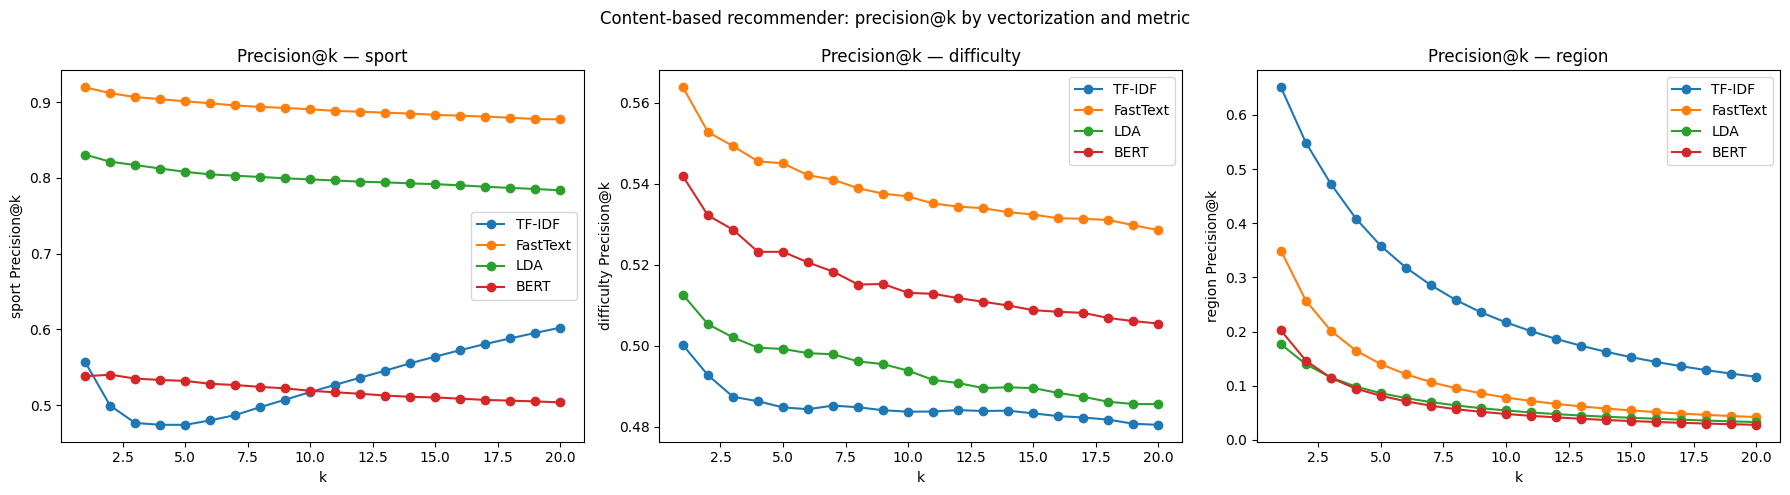


Best vectorization at k=10:
  sport: FastText (0.891)
  difficulty: FastText (0.537)
  region: TF-IDF (0.217)


In [9]:
# Parameter sweep: precision@k for k = 1 to 20, across all metrics
k_values = list(range(1, 21))
metrics = ["sport", "difficulty", "region"]
named_matrices = [("TF-IDF", sim_tfidf), ("FastText", sim_fasttext),
                  ("LDA", sim_lda), ("BERT", sim_bert)]

sweep_results = {metric: {} for metric in metrics}

for metric in metrics:
    if metric not in df.columns:
        continue
    for name, sim_mat in named_matrices:
        sweep_results[metric][name] = [
            precision_at_k(sim_mat, df, metric, k=k) for k in k_values
        ]

# Plot one subplot per metric
fig, axes = plt.subplots(1, len(sweep_results), figsize=(18, 5))

for ax, (metric, model_results) in zip(axes, sweep_results.items()):
    for name, vals in model_results.items():
        ax.plot(k_values, vals, marker="o", label=name)
    ax.set_title(f"Precision@k — {metric}")
    ax.set_xlabel("k")
    ax.set_ylabel(f"{metric} Precision@k")
    ax.legend()

plt.suptitle("Content-based recommender: precision@k by vectorization and metric")
plt.tight_layout()
plt.savefig(DIRECTORY + "/data/precision_at_k_full.png", dpi=150)
plt.show()

# Print best vectorization per metric at k=10
print("\nBest vectorization at k=10:")
for metric, model_results in sweep_results.items():
    best_model = max(model_results, key=lambda m: model_results[m][9])  # index 9 = k=10
    best_score = round(model_results[best_model][9], 3)
    print(f"  {metric}: {best_model} ({best_score})")

FastText dominates sport and difficulty; it understands semantic similarity between trail descriptions best. TF-IDF is solid and consistent. LDA and BERT are both weak, likely because LDA topics are too coarse and BERT was not fine-tuned on trail/outdoor domain text.

Region is interesting: TF-IDF wins hard at k=1 but collapses fast. This makes sense since trail descriptions mention place names directly, so TF-IDF picks up exact location words. But as k grows those exact matches run out. FastText can't match this because place names aren't semantically similar words.

In [10]:
# Best k per vectorization per metric (highest precision point in the sweep)
rows = []
for name, sim_mat in named_matrices:
    row = {"Model": name}
    for metric in metrics:
        if metric not in sweep_results:
            continue
        vals = sweep_results[metric][name]
        best_k = k_values[np.argmax(vals)]
        best_score = round(max(vals), 3)
        row[f"{metric} best P@k"] = best_score
        row[f"{metric} best k"] = best_k
    rows.append(row)

summary_df = pd.DataFrame(rows)
display(summary_df)
summary_df.to_csv(DIRECTORY + "/data/content_based_summary.csv", index=False)

,Model,sport best P@k,sport best k,difficulty best P@k,difficulty best k,region best P@k,region best k
0,TF-IDF,0.602,20,0.500,1,0.651,1
1,FastText,0.920,1,0.564,1,0.350,1
2,LDA,0.831,1,0.513,1,0.177,1
3,BERT,0.540,2,0.542,1,0.202,1


In [11]:
# ── Overall comparison ────────────────────────────────────────────────────────
print("=" * 55)
print("RECOMMENDER SYSTEM — FINAL SUMMARY")
print("=" * 55)
print()
print("Content-based (k=10):")
display(results_df)
print()
print("Best overall vectorization: FastText")
print("  → highest sport and difficulty precision across all k")
print("  → recommended for general trail similarity")
print()
print("Best for location-aware recommendations: TF-IDF")
print("  → highest region precision at small k (k=1..5)")
print("  → degrades quickly as k grows")
print()
print("Collaborative filtering: not evaluable (no real user data)")
print("  → pipeline demonstrated, metrics not interpretable")
print("  → requires individual user interaction logs to evaluate")

RECOMMENDER SYSTEM — FINAL SUMMARY

Content-based (k=10):


,Model,sport P@10,difficulty P@10,region P@10
0,TF-IDF,0.517,0.484,0.217
1,FastText,0.891,0.537,0.078
2,LDA,0.798,0.494,0.054
3,BERT,0.519,0.513,0.048



Best overall vectorization: FastText
  → highest sport and difficulty precision across all k
  → recommended for general trail similarity

Best for location-aware recommendations: TF-IDF
  → highest region precision at small k (k=1..5)
  → degrades quickly as k grows

Collaborative filtering: not evaluable (no real user data)
  → pipeline demonstrated, metrics not interpretable
  → requires individual user interaction logs to evaluate


## Part 2 — Collaborative Filtering

Interaction matrix

In [12]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(seed=42)

# --------------------------------------------------
# Prepare item metadata
# --------------------------------------------------

df_items = df.copy()

df_items["rating_score"] = pd.to_numeric(df_items["rating_score"], errors="coerce")
df_items["rating_count"] = pd.to_numeric(df_items["rating_count"], errors="coerce").fillna(0)
df_items["visitors"] = pd.to_numeric(df_items["visitors"], errors="coerce").fillna(0)

# Fill missing ratings with the global mean only for synthetic interaction generation
global_rating_mean = df_items["rating_score"].mean()
df_items["rating_score_filled"] = df_items["rating_score"].fillna(global_rating_mean)

# Keep only items with essential metadata
df_items = df_items[
    df_items["tour_id"].notna()
    & df_items["sport"].notna()
    & df_items["difficulty"].notna()
].copy()

df_items = df_items.reset_index(drop=True)

print("Items available for CF simulation:", len(df_items))
print("Sports:", df_items["sport"].nunique())
print("Difficulties:", df_items["difficulty"].nunique())
print("Missing filled ratings:", df_items["rating_score_filled"].isna().sum())

Items available for CF simulation: 5642
Sports: 5
Difficulties: 3
Missing filled ratings: 0


In [13]:
# --------------------------------------------------
# Simulate users
# --------------------------------------------------

n_users = 400
min_interactions = 20
max_interactions = 50

sports = df_items["sport"].dropna().unique()
difficulties = df_items["difficulty"].dropna().unique()
regions = df_items["region"].dropna().unique()

interactions = []

for user_id in range(n_users):
    preferred_sport = rng.choice(sports)
    preferred_difficulty = rng.choice(difficulties)
    preferred_region = rng.choice(regions) if len(regions) > 0 else None

    candidate_df = df_items.copy()

    # Preference score based on metadata similarity
    preference_score = (
        2.0 * (candidate_df["sport"] == preferred_sport).astype(float)
        + 1.0 * (candidate_df["difficulty"] == preferred_difficulty).astype(float)
    )

    if preferred_region is not None:
        preference_score += 0.5 * (candidate_df["region"] == preferred_region).astype(float)

    # Popular and well-rated trails are slightly more likely to be selected
    popularity_score = np.log1p(candidate_df["visitors"])
    popularity_score = popularity_score / (popularity_score.max() + 1e-9)

    rating_score = candidate_df["rating_score_filled"] / 5.0

    candidate_df["selection_score"] = (
        preference_score
        + 0.5 * popularity_score
        + 0.5 * rating_score
        + rng.normal(0, 0.2, size=len(candidate_df))
    )

    n_interactions = rng.integers(min_interactions, max_interactions + 1)

    selected = candidate_df.nlargest(n_interactions, "selection_score").copy()

    # Generate synthetic rating
    synthetic_rating = (
        2.5
        + 1.0 * (selected["sport"] == preferred_sport).astype(float)
        + 0.5 * (selected["difficulty"] == preferred_difficulty).astype(float)
        + 0.6 * (selected["rating_score_filled"] - global_rating_mean)
        + rng.normal(0, 0.4, size=len(selected))
    )

    selected["synthetic_rating"] = np.clip(synthetic_rating, 1, 5)
    selected["user_id"] = f"user_{user_id}"

    interactions.append(
        selected[["user_id", "tour_id", "synthetic_rating"]]
    )

df_cf = pd.concat(interactions, ignore_index=True)

print("Synthetic interaction matrix:")
print("Interactions:", len(df_cf))
print("Users:", df_cf["user_id"].nunique())
print("Items:", df_cf["tour_id"].nunique())
print("Rating range:", df_cf["synthetic_rating"].min(), "-", df_cf["synthetic_rating"].max())

display(df_cf.head())

Synthetic interaction matrix:
Interactions: 14287
Users: 400
Items: 3899
Rating range: 2.0681005446316725 - 5.0


,user_id,tour_id,synthetic_rating
0,user_0,e1068074092,4.797067
1,user_0,e1199385314,3.216751
2,user_0,e970383168,3.339277
3,user_0,e1006143374,4.006847
4,user_0,e1025912952,3.362810


In [14]:
from surprise import Dataset, Reader

reader = Reader(rating_scale=(1, 5))

data = Dataset.load_from_df(
    df_cf[["user_id", "tour_id", "synthetic_rating"]],
    reader
)

### Hyperparameter tuning

To avoid using arbitrary parameters, we apply a small grid search to SVD and KNNBasic.  
SVD is tuned over latent factors, epochs, learning rate and regularization.  
KNNBasic is tuned over number of neighbors, minimum neighbors and similarity metric.

The best parameters are selected with 3-fold cross-validation.  
The final models are then evaluated with 5-fold cross-validation using RMSE and MAE.

Since the interaction matrix is synthetic, these results show that the collaborative filtering pipeline works, but they should not be interpreted as real user behaviour.

In [15]:
from surprise.model_selection import GridSearchCV
from surprise import SVD

param_grid_svd = {
    "n_factors": [20, 50, 100],
    "n_epochs": [10, 20, 30],
    "lr_all": [0.002, 0.005, 0.01],
    "reg_all": [0.02, 0.05, 0.1],
    "random_state": [42],
}

gs_svd = GridSearchCV(
    SVD,
    param_grid_svd,
    measures=["rmse", "mae"],
    cv=3,
    n_jobs=-1,
    joblib_verbose=1
)

gs_svd.fit(data)

best_svd_params = gs_svd.best_params["rmse"]
best_svd_rmse = gs_svd.best_score["rmse"]
best_svd_mae = gs_svd.best_score["mae"]

print("Best SVD parameters:", best_svd_params)
print("Best SVD RMSE:", round(best_svd_rmse, 4))
print("Best SVD MAE:", round(best_svd_mae, 4))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  64 tasks      | elapsed:    4.4s


Best SVD parameters: {'n_factors': 20, 'n_epochs': 30, 'lr_all': 0.005, 'reg_all': 0.1, 'random_state': 42}
Best SVD RMSE: 0.4357
Best SVD MAE: 0.347


[Parallel(n_jobs=-1)]: Done 243 out of 243 | elapsed:   25.8s finished


In [16]:
from surprise import KNNBasic

param_grid_knn = {
    "k": [20, 40, 60],
    "min_k": [1, 3],
    "sim_options": {
        "name": ["cosine", "msd"],
        "user_based": [False],
        "min_support": [1, 3],
    },
}

gs_knn = GridSearchCV(
    KNNBasic,
    param_grid_knn,
    measures=["rmse", "mae"],
    cv=3,
    n_jobs=-1,
    joblib_verbose=1
)

gs_knn.fit(data)

best_knn_params = gs_knn.best_params["rmse"]
best_knn_rmse = gs_knn.best_score["rmse"]
best_knn_mae = gs_knn.best_score["mae"]

print("Best KNN parameters:", best_knn_params)
print("Best KNN RMSE:", round(best_knn_rmse, 4))
print("Best KNN MAE:", round(best_knn_mae, 4))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   16.3s


Best KNN parameters: {'k': 40, 'min_k': 3, 'sim_options': {'name': 'msd', 'user_based': False, 'min_support': 3}}
Best KNN RMSE: 0.4488
Best KNN MAE: 0.3571


[Parallel(n_jobs=-1)]: Done  72 out of  72 | elapsed:   24.6s finished


Train models and evaluate with surprise's built-in tools (e.g. cross-validation, RMSE)

In [17]:
from surprise import SVD, KNNBasic, BaselineOnly, NormalPredictor

# Baseline models
def make_normal():
    return NormalPredictor()

def make_baseline():
    return BaselineOnly()

# Tuned SVD using best parameters from GridSearchCV
def make_svd():
    return SVD(**best_svd_params)

# Tuned item-based KNN using best parameters from GridSearchCV
def make_knn():
    return KNNBasic(**best_knn_params)

model_factories = {
    "NormalPredictor": make_normal,
    "BaselineOnly": make_baseline,
    "SVD tuned": make_svd,
    "KNN item-based tuned": make_knn,
}

In [18]:
from surprise.model_selection import cross_validate, KFold
import numpy as np
import pandas as pd

kf = KFold(n_splits=5, random_state=42, shuffle=True)

rows = []

for model_name, make_model in model_factories.items():
    print(f"Evaluating {model_name}...")

    model = make_model()

    cv_result = cross_validate(
        model,
        data,
        measures=["RMSE", "MAE"],
        cv=kf,
        verbose=False
    )

    rows.append({
        "Model": model_name,
        "RMSE mean": np.mean(cv_result["test_rmse"]),
        "RMSE std": np.std(cv_result["test_rmse"]),
        "MAE mean": np.mean(cv_result["test_mae"]),
        "MAE std": np.std(cv_result["test_mae"]),
        "Fit time (s)": np.mean(cv_result["fit_time"]),
    })

cf_results = pd.DataFrame(rows).round(4)
display(cf_results)

best_model_name = cf_results.loc[cf_results["RMSE mean"].idxmin(), "Model"]

print(f"\nBest collaborative filtering model by RMSE: {best_model_name}")
print("Important: these results are based on simulated user-trail interactions.")

Evaluating NormalPredictor...
Evaluating BaselineOnly...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Evaluating SVD tuned...
Evaluating KNN item-based tuned...
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.
Computing the msd similarity matrix...
Done computing similarity matrix.


,Model,RMSE mean,RMSE std,MAE mean,MAE std,Fit time (s)
0,NormalPredictor,0.6189,0.0060,0.4971,0.0062,0.0130
1,BaselineOnly,0.4300,0.0054,0.3424,0.0043,0.0304
2,SVD tuned,0.4317,0.0053,0.3438,0.0043,0.1066
3,KNN item-based tuned,0.4492,0.0069,0.3567,0.0059,0.3163



Best collaborative filtering model by RMSE: BaselineOnly
Important: these results are based on simulated user-trail interactions.


In [19]:
# Train the best collaborative filtering model
final_cf_model = model_factories[best_model_name]()
trainset = data.build_full_trainset()
final_cf_model.fit(trainset)

print(f"Final collaborative filtering model trained: {best_model_name}")

Estimating biases using als...
Final collaborative filtering model trained: BaselineOnly


In [20]:
def recommend_cf(user_id, model, df_items, df_cf, n=5):
    """
    Recommend trails for a synthetic user using a trained Surprise model.
    Already interacted items are excluded.
    """

    all_items = df_items["tour_id"].unique()

    seen_items = set(
        df_cf.loc[df_cf["user_id"] == user_id, "tour_id"].unique()
    )

    preds = []

    for item in all_items:
        if item not in seen_items:
            pred = model.predict(user_id, item)
            preds.append((item, pred.est))

    preds.sort(key=lambda x: x[1], reverse=True)

    top_items = [item for item, _ in preds[:n]]

    return df_items[df_items["tour_id"].isin(top_items)][
        ["tour_id", "name", "sport", "difficulty", "region", "rating_score", "visitors"]
    ]

In [21]:
example_user = "user_0"

recommend_cf(
    user_id=example_user,
    model=final_cf_model,
    df_items=df_items,
    df_cf=df_cf,
    n=5
)

,tour_id,name,sport,difficulty,region,rating_score,visitors
102,e1005125673,Santander Bay and Pas Greenway Loop,racebike,easy,Costera,5.0,35
513,e1021539394,Guadiana Natural Trail,touringbicycle,easy,Guadiana,5.0,43
1687,e1120508276,Tour of Biscay Trail,jogging,moderate,Portugalete,5.0,294
3221,e1421067911,Rota Vicentina - Fishermen's Trail,jogging,difficult,Lagos (Santa Maria),5.0,258
3627,e872756397,Mirador Morro de Toix Trail,jogging,difficult,Altea,5.0,18


In [22]:
cf_results.to_csv(DATA_DIR / "collaborative_filtering_results.csv", index=False)

print("Saved collaborative filtering results to:")
print(DATA_DIR / "collaborative_filtering_results.csv")

Saved collaborative filtering results to:
/content/drive/MyDrive/ml-applications-project-repo/data/collaborative_filtering_results.csv


In [23]:
print("df:", df.shape)
print("TF-IDF:", tfidf_matrix.shape)
print("FastText:", fasttext_matrix.shape)
print("LDA:", lda_matrix.shape)
print("BERT:", bert_matrix.shape)

assert len(df) == tfidf_matrix.shape[0]
assert len(df) == fasttext_matrix.shape[0]
assert len(df) == lda_matrix.shape[0]
assert len(df) == bert_matrix.shape[0]

print("All dimensions match.")

df: (5642, 45)
TF-IDF: (5642, 5000)
FastText: (5642, 100)
LDA: (5642, 15)
BERT: (5642, 384)
All dimensions match.
